C:\Users\minkyu\AppData\Local\Temp\ipykernel_19192\1994271511.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load('savepoints/autoenc

Latent data shape for digit 0: (1000, 32)
Latent data shape for digit 1: (1000, 32)
Latent data shape for digit 2: (1000, 32)
Latent data shape for digit 3: (1000, 32)
Latent data shape for digit 4: (1000, 32)
Latent data shape for digit 5: (1000, 32)
Latent data shape for digit 6: (1000, 32)
Latent data shape for digit 7: (1000, 32)
Latent data shape for digit 8: (1000, 32)
Latent data shape for digit 9: (1000, 32)


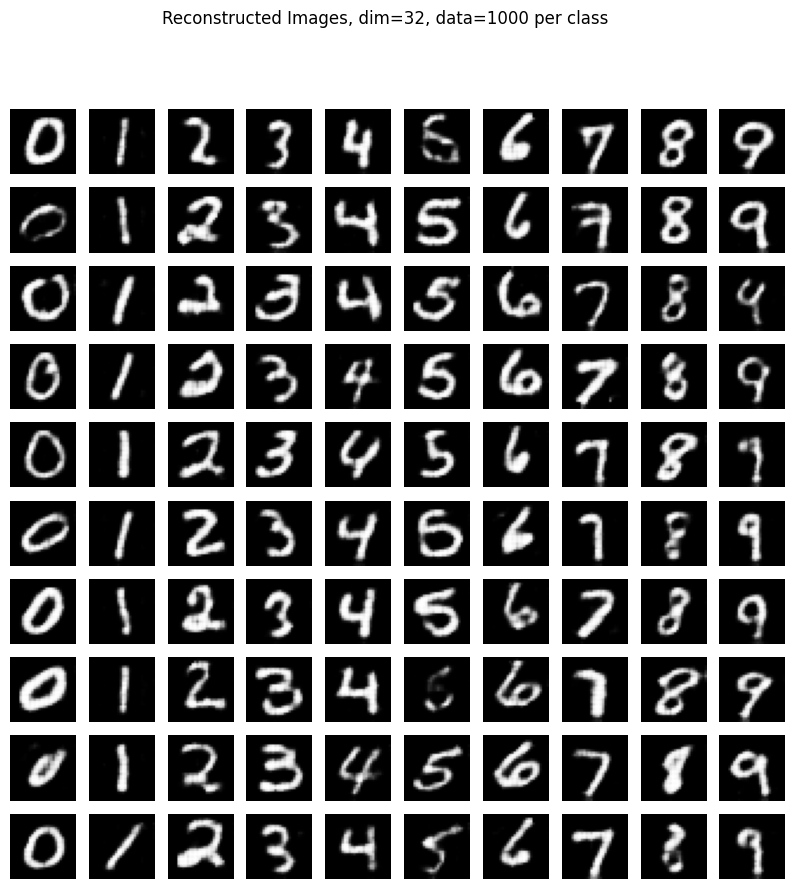

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import importlib

from modules import Autoencoder
importlib.reload(Autoencoder)  # 모듈 갱신

# 오토인코더 모델 로드
latent_dim = 32
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
autoencoder.load_state_dict(torch.load('savepoints/autoencoder.pth'))
autoencoder.eval()  # 평가 모드로 전환

num_images_per_class = 1000

# 데이터 로드
data = np.load(f'./data/MNIST/mnist_{num_images_per_class}.npz')

# 클래스별로 10개의 latent 벡터를 선택하고 복원
reconstructed_images = []
for digit in range(10):
    latent_data = data[f'{digit}_latent']  # 각 클래스의 latent 벡터 불러오기
    
    print(f"Latent data shape for digit {digit}:", latent_data.shape)
    # 10개의 latent 벡터를 텐서로 변환
    latent_vectors = torch.tensor(latent_data[:10], dtype=torch.float32)
    
    # 오토인코더의 디코더로 복원
    with torch.no_grad():
        reconstructed = autoencoder.decoder(latent_vectors)  # (10, 1, 28, 28)
    reconstructed_images.append(reconstructed)

# 10x10 그리드에 시각화
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
    for j in range(10):
        # (1, 28, 28) 형태를 (28, 28)으로 변환하여 시각화
        axs[j, i].imshow(reconstructed_images[i][j].squeeze().detach().numpy(), cmap='gray')
        axs[j, i].axis('off')

plt.suptitle(f"Reconstructed Images, dim={latent_dim}, data={num_images_per_class} per class")
plt.show()
